In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("messy_churn_data.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      10020 non-null  str    
 1   Gender          10020 non-null  str    
 2   Age             9219 non-null   float64
 3   SignUpDate      10020 non-null  str    
 4   Contract        10020 non-null  str    
 5   PaymentMethod   10020 non-null  str    
 6   TenureMonths    10020 non-null  int64  
 7   MonthlyCharges  10020 non-null  float64
 8   TotalCharges    9023 non-null   str    
 9   Churn           10020 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 782.9 KB


In [5]:
df["Age"].value_counts(dropna=False)

Age
 NaN     801
 41.0    320
 45.0    313
 37.0    311
 38.0    308
        ... 
-4.0       1
 78.0      1
-0.0       1
 81.0      1
 80.0      1
Name: count, Length: 87, dtype: int64

In [6]:

def free_space(df):
    for col in df.columns:
        count=0
        for element in df[col]:
            if element == ' ' or element == "unknown":
                count+=1
        print(f"Column {col} has {count} free spaces")

free_space(df)
       


Column CustomerID has 0 free spaces
Column Gender has 0 free spaces
Column Age has 0 free spaces
Column SignUpDate has 0 free spaces
Column Contract has 0 free spaces
Column PaymentMethod has 500 free spaces
Column TenureMonths has 0 free spaces
Column MonthlyCharges has 0 free spaces
Column TotalCharges has 0 free spaces
Column Churn has 0 free spaces


In [7]:
df["Age"].where(df["Age"]<=18).value_counts()

Age
 18.0    58
 17.0    54
 16.0    52
 15.0    35
 12.0    22
 14.0    19
 13.0    19
 11.0    18
 10.0    18
 9.0     13
 8.0     13
 7.0      6
-5.0      6
 6.0      4
 5.0      3
 4.0      3
 1.0      2
 3.0      2
-1.0      2
 2.0      1
-2.0      1
-4.0      1
-0.0      1
Name: count, dtype: int64

In [8]:
df["Age"].median()

np.float64(40.0)

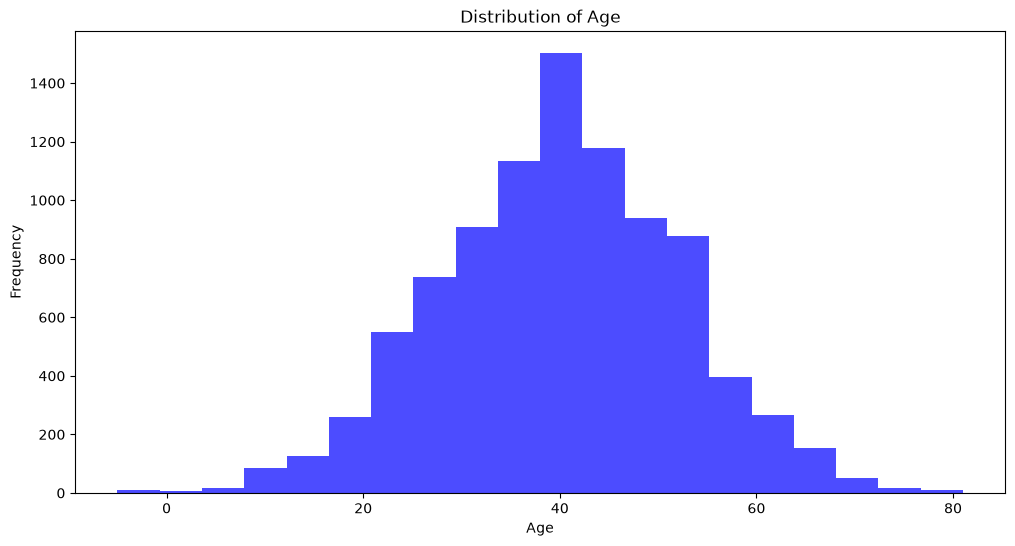

In [9]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Age")
plt.hist(df["Age"], bins=20, color="blue", alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

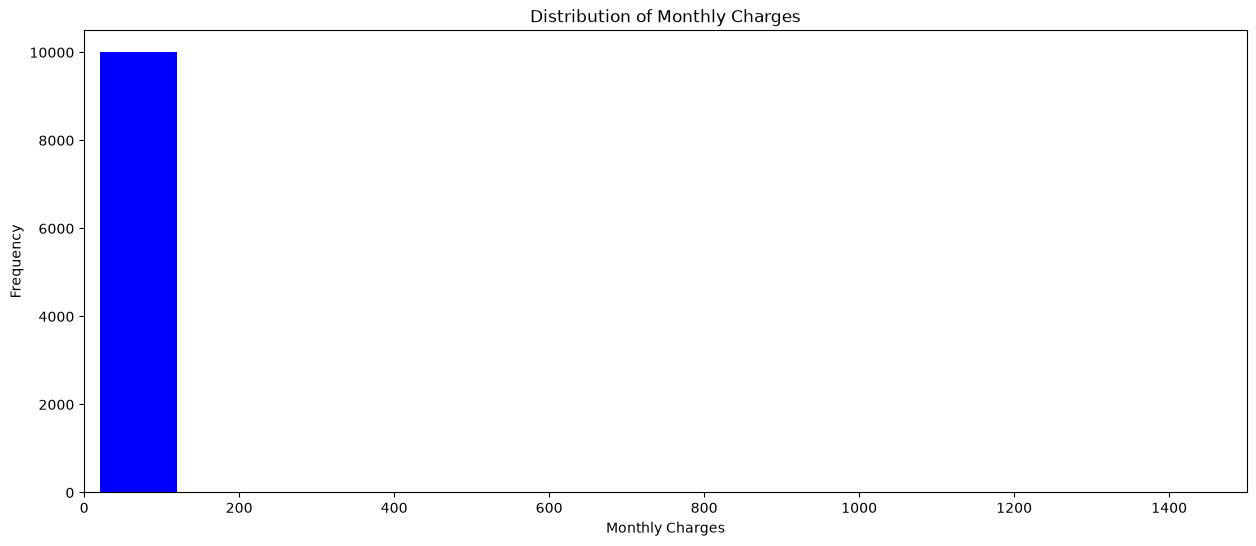

In [10]:
plt.figure(figsize=(15,6))
plt.title("Distribution of Monthly Charges")
plt.hist(df["MonthlyCharges"], bins=100, color="blue")
plt.xlabel("Monthly Charges")
plt.xlim(0, 1500)
plt.ylabel("Frequency")
plt.show()

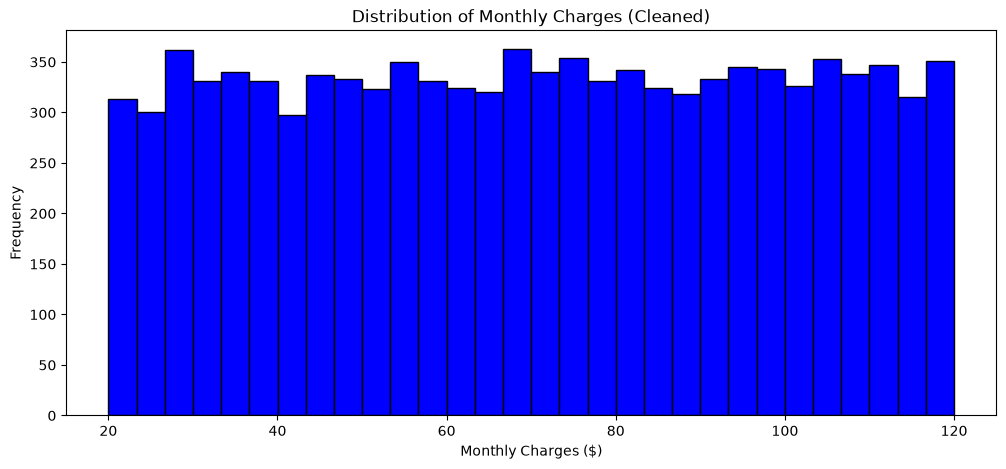

In [12]:
import numpy as np

# استبعاد القيم الشاذة وتحويلها لـ NaN
df.loc[(df['MonthlyCharges'] < 0) | (df['MonthlyCharges'] > 150), 'MonthlyCharges'] = np.nan

# دلوقتي ارسم الـ Histogram عادي جداً من غير plt.xlim
plt.figure(figsize=(12, 5))
plt.hist(df['MonthlyCharges'].dropna(), bins=30, color='blue', edgecolor='black')
plt.title("Distribution of Monthly Charges (Cleaned)")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Frequency")
plt.show()

In [13]:
df.iloc[df[df["MonthlyCharges"].isna()].index]

,CustomerID,Gender,Age,SignUpDate,Contract,PaymentMethod,TenureMonths,MonthlyCharges,TotalCharges,Churn
3986,CUST-4986,Female,44.0,INVALID_DATE,Month-to-month,Electronic check,47,NaN,5013.49,0
6035,CUST-7035,M,NaN,INVALID_DATE,Month-to-month,Credit card,39,NaN,3835.6499999999996,0
9143,CUST-10143,Female,37.0,01/13/2046,Two year,Mailed check,11,NaN,395.56,1
9227,CUST-10227,female,48.0,04/07/2046,month-to-month,Credit card,46,NaN,4993.76,0
9337,CUST-10337,Male,NaN,INVALID_DATE,1 Year,,59,NaN,4597.870000000001,1


In [14]:
df[df["MonthlyCharges"].isna()].index

Index([3986, 6035, 9143, 9227, 9337], dtype='int64')

In [15]:
df.iloc[3986]

CustomerID               CUST-4986
Gender                      Female
Age                           44.0
SignUpDate            INVALID_DATE
Contract            Month-to-month
PaymentMethod     Electronic check
TenureMonths                    47
MonthlyCharges                 NaN
TotalCharges               5013.49
Churn                            0
Name: 3986, dtype: object

In [16]:
df[df["MonthlyCharges"]>120]

,CustomerID,Gender,Age,SignUpDate,Contract,PaymentMethod,TenureMonths,MonthlyCharges,TotalCharges,Churn


## تحويل المسافات والنصوص الشاذة إلى NaN

In [18]:
import numpy as np
import pandas as pd

# 1. إزالة المسافات الزائدة من كل الأعمدة النصية أولاً
categorical_cols = df.select_dtypes(include=['object','string', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# 2. استبدال المسافات الفارغة والنصوص الشاذة بـ NaN
df.replace(['', ' ', 'Unknown', 'INVALID_DATE'], np.nan, inplace=True)

# دلوقتي لو عملت ده هتظهرلك كل القيم المفقودة الحقيقية!
print(df.isnull().sum())

CustomerID           0
Gender               0
Age                801
SignUpDate        2581
Contract             0
PaymentMethod      500
TenureMonths         0
MonthlyCharges       5
TotalCharges      1012
Churn                0
dtype: int64


## Categorical Inconsistencies

In [19]:
# توحيد عمود Gender
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female',
    'female': 'Female'
})

# توحيد عمود Contract
df['Contract'] = df['Contract'].replace({
    'month-to-month': 'Month-to-month',
    '1 Year': 'One year'
})

## repair data types

In [20]:
# إزالة علامة $ وتحويل العمود لـ float
df['TotalCharges'] = df['TotalCharges'].astype(str).str.replace('$', '', regex=False)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # errors='coerce' بتحول أي قيمة غير رقمية لـ NaN تلقائياً

## Dates

In [28]:
# تحويل التواريخ لصيغة موحدة وإجبار التواريخ الخاطئة تتسجل كـ NaT (NaN للتواريخ)
df['SignUpDate'] = pd.to_datetime(df['SignUpDate'], format='mixed', errors='coerce')

## Outliers


In [23]:
# طريقة الـ IQR لتحديد Outliers تلقائياً
for col in ['MonthlyCharges', 'Age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # استبدال القيم الخارجة عن الحدود بـ NaN
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

## Duplicates

In [24]:
# مسح الصفوف المتكررة بالكامل
df = df.drop_duplicates().reset_index(drop=True)

## Imputation

In [25]:
# تعويض الأرقام بالـ Median (الوسيط) لأنه أفضل مع Outliers
df['Age'] = df['Age'].fillna(df['Age'].median())
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# تعويض الفئات بالنص الأكثر تكراراً (Mode)
df['PaymentMethod'] = df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0])

In [29]:
missing_mask = df['SignUpDate'].isna()
missing_mask

0        True
1       False
2       False
3       False
4       False
        ...  
9995     True
9996     True
9997     True
9998     True
9999     True
Name: SignUpDate, Length: 10000, dtype: bool

In [32]:
import pandas as pd
df['SignUpDate'] = df['SignUpDate'].astype('datetime64[ns]')

# 1. تحويل التواريخ المستقبلية (أكبر من أغسطس 2026) إلى NaT
cutoff_date = pd.to_datetime('2026-08-31')
df.loc[df['SignUpDate'] > cutoff_date, 'SignUpDate'] = pd.NaT

# 2. تحديد أحدث تاريخ منطقي متبقي
max_valid_date = df['SignUpDate'].max()

# 3. إعادة الحساب العكسي للتواريخ المفقودة من TenureMonths
missing_mask = df['SignUpDate'].isna()
df.loc[missing_mask, 'SignUpDate'] = max_valid_date - pd.to_timedelta(df.loc[missing_mask, 'TenureMonths'] * 30.44, unit='D')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      10000 non-null  str           
 1   Gender          10000 non-null  str           
 2   Age             10000 non-null  float64       
 3   SignUpDate      10000 non-null  datetime64[ns]
 4   Contract        10000 non-null  str           
 5   PaymentMethod   10000 non-null  str           
 6   TenureMonths    10000 non-null  int64         
 7   MonthlyCharges  10000 non-null  float64       
 8   TotalCharges    10000 non-null  float64       
 9   Churn           10000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), str(4)
memory usage: 781.4 KB


In [35]:
df["SignUpDate"].isnull().sum()

np.int64(0)

In [36]:
for col in ['Gender', 'Contract', 'PaymentMethod']:
    print(col, "-->", df[col].unique())

Gender --> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Contract --> <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod --> <StringArray>
['Mailed check', 'Electronic check', 'Bank transfer', 'Credit card']
Length: 4, dtype: str


In [37]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


## Feature engineering and encoding 

In [38]:
df['SignUp_Year'] = df['SignUpDate'].dt.year
df['SignUp_Month'] = df['SignUpDate'].dt.month

# حذف عمود التاريخ الأصلي وعمود CustomerID لأنهم مش مفيدين للموديل
df.drop(columns=['SignUpDate', 'CustomerID'], inplace=True)

In [39]:
df = pd.get_dummies(df, columns=['Gender', 'Contract', 'PaymentMethod'], drop_first=True, dtype=int)

In [40]:
df.tail()

,Age,TenureMonths,MonthlyCharges,TotalCharges,Churn,SignUp_Year,SignUp_Month,Gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
9995,45.0,47,91.17,4284.99,0,2022,9,0,1,0,0,0,1
9996,61.0,20,100.48,2009.60,1,2024,12,0,1,0,0,1,0
9997,41.0,6,99.61,597.66,1,2026,3,0,1,0,0,1,0
9998,53.0,29,55.77,1617.33,0,2024,3,0,1,0,0,1,0
9999,22.0,49,68.22,3342.78,0,2022,7,0,0,0,0,0,1


In [41]:
df.shape

(10000, 13)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             10000 non-null  float64
 1   TenureMonths                    10000 non-null  int64  
 2   MonthlyCharges                  10000 non-null  float64
 3   TotalCharges                    10000 non-null  float64
 4   Churn                           10000 non-null  int64  
 5   SignUp_Year                     10000 non-null  int32  
 6   SignUp_Month                    10000 non-null  int32  
 7   Gender_Male                     10000 non-null  int64  
 8   Contract_One year               10000 non-null  int64  
 9   Contract_Two year               10000 non-null  int64  
 10  PaymentMethod_Credit card       10000 non-null  int64  
 11  PaymentMethod_Electronic check  10000 non-null  int64  
 12  PaymentMethod_Mailed check      10000 non-nu

In [45]:
# حفظ البيانات المنظفة في ملف جديد
df.to_csv('churn_cleaned_data.csv', index=False)